Analyses corresponding to Supplementary Figure S2

In [ ]:
import numpy as np
import pandas as pd
from joypy import joyplot
import matplotlib.pyplot as plt

/home/AD/vbidhan/mosaic3.12/lib/python3.10/site-packages/missionbio/mosaic/io.py:47: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
parquet_dir = "/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/parquets/"
AF_final = pd.read_parquet(f"{parquet_dir}AF_filtered_STG_final.parquet")
DP_final = pd.read_parquet(f"{parquet_dir}DP_filtered_STG_final.parquet")
NGT_final = pd.read_parquet(f"{parquet_dir}NGT_filtered_STG_final.parquet")

In [3]:
print(NGT_final.shape)
print(DP_final.shape)
print(AF_final.shape)

(39800, 28345)
(39800, 28345)
(39800, 28345)


In [4]:
def annotate_spliceai_effect(df: pd.DataFrame) -> pd.DataFrame:
    cols = ['SpliceAI_pred_DS_AG','SpliceAI_pred_DS_AL','SpliceAI_pred_DS_DG','SpliceAI_pred_DS_DL']
    labels = ['acceptor_gain', 'acceptor_loss','donor_gain','donor_loss']
    ds_matrix = (df[cols].apply(pd.to_numeric, errors='coerce').fillna(0).to_numpy())
    max_idx = ds_matrix.argmax(axis=1)
    max_score = ds_matrix.max(axis=1)

    # Map severity
    severity = np.select(
        [max_score >= 0.8,max_score >= 0.5,max_score >= 0.2],
        ['high','moderate','low'],
        default='none'
    )
    # Map effect
    effect = [labels[i] for i in max_idx]
    effect = np.where(max_score == 0, 'none', effect)
    df['spliceai_severity'] = severity
    df['spliceai_effect'] = effect

    return df

def categorize_hc_lof(row) -> str:
    lof_flag = str(row.get("LoF", "")).upper()
    spliceai_sev = str(row.get("spliceai_severity", "")).lower()
    if lof_flag in {"HC", "OS"} or spliceai_sev == "high":
        return "Yes"
    return np.nan

output_dir = "/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data"

LOF = {
    "stop_gained", "frameshift_variant", "stop_gained&frameshift_variant",
    "splice_acceptor_variant", "splice_donor_variant",
    "stop_gained&splice_region_variant", "frameshift_variant&splice_region_variant"
}

indel_terms = [
    "frameshift_variant",
    "frameshift_variant&splice_region_variant",
    "stop_gained&frameshift_variant",
    "stop_gained&inframe_deletion",
    "inframe_deletion",
    "inframe_insertion",
    "frameshift_variant&stop_lost",
    "frameshift_variant&start_lost",
]

non_coding_terms = [
    "intron_variant",
    "splice_polypyrimidine_tract_variant&intron_variant",
    "splice_region_variant&splice_polypyrimidine_tract_variant&intron_variant",
    "splice_donor_region_variant&intron_variant",
    "splice_region_variant&5_prime_UTR_variant",
    "splice_donor_5th_base_variant&intron_variant",
    "splice_region_variant&intron_variant",
    "3_prime_UTR_variant",
    "5_prime_UTR_variant",
    # "splice_acceptor_variant", "splice_donor_variant"
]

splice_site_terms = ["splice_acceptor_variant", "splice_donor_variant"]
missense_terms = ["missense_variant", "missense_variant&splice_region_variant"]
nonsense_terms = ["stop_gained", "stop_gained&splice_region_variant", "stop_gained&frameshift_variant", "stop_gained&inframe_deletion"]
frameshift_terms = ["frameshift_variant", "frameshift_variant&splice_region_variant", "frameshift_variant&stop_lost", "frameshift_variant&start_lost"]
synonymous_terms = ['synonymous_variant', 'stop_retained_variant', 'splice_region_variant&synonymous_variant']
nonsynonymous_terms = [
    "start_lost",
    "missense_variant",
    "frameshift_variant",
    "stop_gained",
    "missense_variant&splice_region_variant",
    "inframe_deletion",
    "frameshift_variant&splice_region_variant",
    "inframe_insertion",
    "stop_gained&splice_region_variant",
    "stop_lost",
    "stop_gained&frameshift_variant",
    "frameshift_variant&stop_lost",
    "stop_gained&inframe_deletion",
    "frameshift_variant&start_lost",
]

parquet_dir = "/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/parquets/"
AF_FILTERED = pd.read_parquet(f"{parquet_dir}AF_filtered_STG_final.parquet")
DP = pd.read_parquet(f"{parquet_dir}DP_filtered_STG_final.parquet")
metadata_filtered = pd.read_parquet(f"{parquet_dir}metadata_filtered_repeats_germline_freq.parquet")
GQ = pd.read_parquet(f"{parquet_dir}GQ_filtered_STG_final.parquet")
NGT_final = pd.read_parquet(f"{parquet_dir}NGT_filtered_STG_final.parquet")

metadata_filtered['age_at_death'] = metadata_filtered['age_at_death'].astype(str).str.replace(',', '.', regex=False)
metadata_filtered = metadata_filtered.loc[NGT_final.index]

# Load annotations
annotations = pd.read_csv('/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/Annotations_STG.csv', sep='\t', header=0) 
annotations['Protein_annotation'] = annotations['HGVSp'].str.split(".", expand=True)[2]

annotations = annotations[annotations['variant_id'].isin(NGT_final.columns)]
annotate_spliceai_effect(annotations)

genes = ["TARDBP", "TET2", "TMEM106B", "OPTN", "TBK1", "GRN", "UNC13A"]

annotations_df = []
NGT_list_filtered = []
NGT_patients_list = []
NGT_controls_list = []

ann_all_vars_list = []
ann_all_snv_list = []
ann_all_indels_list = []

ann_coding_list = []
ann_indels_list = []
ann_snv_list = []

ann_nonsyn_list = []
ann_syn_list = []
ann_missense_list = []
ann_nonsense_list = []
ann_frameshift_list = []
ann_splicesite_list = []
ann_startloss_list = []
ann_stoploss_list = []
cadd_above20_list = []
ann_LOF_list = []
ann_HC_LOF_list = []


var_groups_dict = {}
burden_dict = {}
var_groups_names = [
    "Coding_variants", "SNVs", "Indels", "Synonymous",
    "Non_synonymous", "Missense", "Nonsense",
    "Frameshift", "Splice site", "LOF", "HC_LOF", "CADD_atleast20",
]

for i, gene_name in enumerate(genes):
    ann = annotations[annotations['SYMBOL']==gene_name].copy()
    ann.index = ann['variant_id']
    ann["HC_LOF"] = ann.apply(categorize_hc_lof,  axis=1)
    ann = ann.set_index('variant_id')

    vars = ann.index.tolist()
    NGT = NGT_final.loc[:, vars].copy()
    meta = metadata_filtered.reindex(NGT.index).copy()

    NGT = NGT.assign(
        sample_identifier = meta['ID'],
        sample_id         = meta['sample_id'],
        sample_type       = meta['sample_type'],
        age_at_death      = meta['age_at_death'].to_numpy(),
        age_at_onset      = meta['age_at_onset'].to_numpy(),
        hemisphere        = meta['hemisphere'],
    )
    NGT_list_filtered.append(NGT)
    
    NGT_controls = NGT[NGT['sample_type'] == "C"]
    NGT_patients = NGT[NGT['sample_type'] == "P"]

    counts = pd.DataFrame({
        "cell_count_patients": NGT_patients.iloc[:, :-6].isin([1, 2]).sum(),
        "total_genotyped_cells_P": NGT_patients.iloc[:, :-6].isin([0, 1, 2]).sum()
    })
    counts["mutation_freq_P"] = counts["cell_count_patients"] / counts["total_genotyped_cells_P"] * 100
    ann = ann.merge(counts, left_index=True, right_index=True, how="inner")

    counts_C = pd.DataFrame({
        "cell_count_controls": NGT_controls.iloc[:, :-6].isin([1, 2]).sum(),
        "total_genotyped_cells_C": NGT_controls.iloc[:, :-6].isin([0, 1, 2]).sum()
    })
    counts_C["mutation_freq_C"] = counts_C["cell_count_controls"] / counts_C["total_genotyped_cells_C"] * 100
    ann = ann.merge(counts_C, left_index=True, right_index=True, how="inner")
    ann["total_cells"] = ann["cell_count_patients"] + ann["cell_count_controls"]
    ann["total_genotyped_cells"] = ann['total_genotyped_cells_P'] + ann['total_genotyped_cells_C']
    ann['total_freq'] = ann["total_cells"]/ann['total_genotyped_cells']*100

    annotations_df.append(ann)
    NGT_patients_list.append(NGT_patients)
    NGT_controls_list.append(NGT_controls)

    lengths_ref = ann['REF'].apply(len)
    length_alt = ann['ALT'].apply(len)
    indels = (lengths_ref[lengths_ref >1].index.to_list()) + (length_alt[length_alt >1].index.to_list()) # Count total number of indels
    indels = list(set(indels))
    ann_all_snv = ann.drop(index = indels) # To calculate total number of SNVs
    ann_all_indels = ann.loc[indels]

    ann_coding = ann[~ann['Consequence'].isin(non_coding_terms)]
    ann_indel = ann_coding[ann_coding['Consequence'].isin(indel_terms)] #Indels in coding regions 
    ann_snv = ann_coding[~ann_coding['Consequence'].isin(indel_terms)] # SNVs in coding regions
    
    ann_nonsyn = ann_coding[ann_coding['Consequence'].isin(nonsynonymous_terms)]
    ann_syn = ann_coding[ann_coding['Consequence'].isin(synonymous_terms)]
    ann_missense = ann_coding[ann_coding['Consequence'].isin(missense_terms)]
    ann_nonsense = ann_coding[ann_coding['Consequence'].isin(nonsense_terms)]
    ann_frameshift = ann_coding[ann_coding['Consequence'].isin(frameshift_terms)]
    ann_splicesite = ann_coding[ann_coding['Consequence'].isin(splice_site_terms)]
    ann_startloss = ann_coding[ann_coding['Consequence'].isin(["start_lost"])]
    ann_stoploss = ann_coding[ann_coding['Consequence'].isin(["stop_lost"])]
    ann_lof = ann_coding[ann_coding['Consequence'].isin(list(LOF))]
    ann_lof_hf = ann_lof[ann_lof['HC_LOF']=="Yes"]
    cadd_above20 = ann_snv[ann_snv['CADD_PHRED'] >= 20]

    ann_all_vars_list.append(ann)
    ann_all_snv_list.append(ann_all_snv)
    ann_all_indels_list.append(ann_all_indels)
    ann_snv_list.append(ann_snv)
    ann_indels_list.append(ann_indel)
    ann_coding_list.append(ann_coding)
    ann_nonsyn_list.append(ann_nonsyn)
    ann_syn_list.append(ann_syn)

    ann_missense_list.append(ann_missense)
    ann_nonsense_list.append(ann_nonsense)
    ann_frameshift_list.append(ann_frameshift)
    ann_splicesite_list.append(ann_splicesite)
    ann_startloss_list.append(ann_startloss)
    ann_stoploss_list.append(ann_stoploss)
    ann_LOF_list.append(ann_lof)
    ann_HC_LOF_list.append(ann_lof_hf)
    cadd_above20_list.append(cadd_above20)

    var_groups_dict[gene_name] = {
        group_name: group_list[i]
        for group_name, group_list in zip(
            var_groups_names,
            [
                ann_coding_list,
                ann_snv_list,
                ann_indels_list,
                ann_syn_list,
                ann_nonsyn_list,
                ann_missense_list,
                ann_nonsense_list,
                ann_frameshift_list,
                ann_splicesite_list,
                ann_LOF_list,
                ann_HC_LOF_list,
                cadd_above20_list

            ]
        )
    }

    df = NGT.copy()
    ids_selected = df['sample_id'].unique()
    list_vars = var_groups_dict[gene_name]
    

/tmp/ipykernel_385454/1945379322.py:94: DtypeWarning:

Columns (37,39,76) have mixed types. Specify dtype option on import or set low_memory=False.



In [5]:
all_coding_vars  = []
for i in range(len(ann_coding_list)):
    all_coding_vars.extend(ann_coding_list[i].index.to_list())
len(all_coding_vars)

19102

In [6]:
NGT = NGT_final[all_coding_vars]
AF = AF_FILTERED[all_coding_vars]
DP = DP_final[all_coding_vars]

print(NGT.shape)
print(AF.shape)
print(DP.shape)

(39800, 19102)
(39800, 19102)
(39800, 19102)


In [7]:
DP = DP.copy()
DP['ID'] = metadata_filtered['ID']
DP['age_at_death'] = metadata_filtered['age_at_death']
DP['sample_id'] = metadata_filtered['sample_id']
DP['sex'] = metadata_filtered['sex']
DP['sample_type'] = metadata_filtered['sample_type']
DP['hemisphere'] = metadata_filtered['hemisphere']

In [8]:
for i, gene in enumerate(genes):
    print(gene)
    DP_gene = DP[ann_coding_list[i].index]

    parts = DP_gene.columns.to_series().str.split(":", expand=True)
    DP_gene.columns = parts.iloc[:, 1].to_numpy()
    DP_gene = DP_gene.loc[:, ~DP_gene.columns.duplicated()].copy()

    coverage = pd.DataFrame(DP_gene.median(axis=1, numeric_only=True), columns=["coverage"])

    DP_gene['ID'] = metadata_filtered['ID']
    DP_gene['sample_id'] = metadata_filtered['sample_id']
    DP_gene['sample_type'] = metadata_filtered['sample_type']

    coverage['sample_type'] = DP_gene['sample_type']
    coverage['ID'] = DP_gene['ID']
    coverage = coverage.sort_values(by="coverage")

    # report median and mean coverage per gene
    print(coverage['coverage'].median())
    print(np.round(coverage['coverage'].mean(), 2))
    print("\n")


TARDBP
92.0
146.23


TET2
125.0
186.26


TMEM106B
62.0
118.47


OPTN
97.0
159.14


TBK1
107.0
189.55


GRN
31.0
47.18


UNC13A
65.0
90.07




Coverage across all coding positions in STG samples post variant filtering

In [9]:
# For all samples 
coverage_distribution_allsamples = []
sample_types = []
medians = []
medians_patients = []
medians_controls = []
for id in DP['ID'].unique():
    df_sample = DP[DP['ID']==id]
    coverage_distribution = pd.DataFrame(df_sample.iloc[:,:-6].median(axis=1))
    coverage_distribution['sample_type'] = df_sample['sample_type']
    coverage_distribution['ID'] = df_sample['ID']
    coverage_distribution.columns = ["coverage", "sample_type", "ID"]
    coverage_distribution = coverage_distribution.sort_values(by="coverage")
    coverage_distribution_allsamples.append(coverage_distribution)
    sample_median = coverage_distribution["coverage"].median()
    medians.append(sample_median)
    if DP[DP["ID"] == id]["sample_type"].unique().tolist() == ["P"]:
        medians_patients.append(sample_median)
    if DP[DP["ID"] == id]["sample_type"].unique().tolist() == ["C"]:
        medians_controls.append(sample_median)

In [10]:
data_dict = {'coverage_distribution': coverage_distribution_allsamples, 'median': medians}

# Ensure all DataFrames have identical labels
coverage_distribution_allsamples = [df.reset_index(drop=True) for df in coverage_distribution_allsamples]

# Sort coverage_distribution based on descending order of medians
coverage_distribution_allsamples_sorted = [
    x for _, x in sorted(
        zip(data_dict['median'], data_dict['coverage_distribution']),
        key=lambda pair: pair[0],  # Sort by median
        reverse=False               # Descending order
    )
]

In [11]:
combined_df = pd.concat(coverage_distribution_allsamples_sorted, axis=0, ignore_index=False)
combined_df.columns = ['Value', 'sample_type', 'ID']
color_mapping = {'C': 'blue', 'P': 'red'}
combined_df['Color'] = combined_df['sample_type'].map(color_mapping)

control_df = combined_df[combined_df['sample_type'] == 'C']
condition_df = combined_df[combined_df['sample_type'] == 'P']

# Categorise to make sure data is plotted based on sorting of means of distribution 
id_order = control_df['ID'].unique() 
control_df = control_df.copy()
control_df['ID'] = pd.Categorical(control_df['ID'], categories=id_order, ordered=True)

id_order2 = condition_df['ID'].unique() 
condition_df = condition_df.copy()
condition_df['ID'] = pd.Categorical(condition_df['ID'], categories=id_order2, ordered=True)

In [12]:
# extract unique positions from DP column names (excluding metadata columns)
def get_unique_pos_cols(dp_df, n_meta_cols=6):
    all_cols = dp_df.iloc[:, :-n_meta_cols].columns.tolist()
    seen_pos = set()
    unique_cols = []
    for col in all_cols:
        parts = col.split(':')
        if len(parts) >= 2:
            pos = parts[1]
            if pos not in seen_pos:
                seen_pos.add(pos)
                unique_cols.append(col)
    return unique_cols

# get deduplicated position columns once
unique_pos_cols = get_unique_pos_cols(DP)

# for all samples
coverage_distribution_allsamples = []
sample_types = []
medians = []
medians_patients = []
medians_controls = []

for id in DP['ID'].unique():
    df_sample = DP[DP['ID'] == id]
    
    # use deduplicated position columns
    coverage_distribution = pd.DataFrame(
        df_sample[unique_pos_cols].median(axis=1),
        columns=['coverage']
    )
    coverage_distribution['sample_type'] = df_sample['sample_type'].values
    coverage_distribution['ID'] = df_sample['ID'].values
    coverage_distribution = coverage_distribution.sort_values(by="coverage")
    coverage_distribution_allsamples.append(coverage_distribution)
    
    sample_median = coverage_distribution["coverage"].median()
    medians.append(sample_median)
    
    if DP[DP["ID"] == id]["sample_type"].unique().tolist() == ["P"]:
        medians_patients.append(sample_median)
    if DP[DP["ID"] == id]["sample_type"].unique().tolist() == ["C"]:
        medians_controls.append(sample_median)

data_dict = {'coverage_distribution': coverage_distribution_allsamples, 'median': medians}

coverage_distribution_allsamples = [df.reset_index(drop=True) for df in coverage_distribution_allsamples]

coverage_distribution_allsamples_sorted = [
    x for _, x in sorted(
        zip(data_dict['median'], data_dict['coverage_distribution']),
        key=lambda pair: pair[0],
        reverse=False
    )
]

combined_df = pd.concat(coverage_distribution_allsamples_sorted, axis=0, ignore_index=False)
combined_df.columns = ['Value', 'sample_type', 'ID']

color_mapping = {'C': 'blue', 'P': 'red'}
combined_df['Color'] = combined_df['sample_type'].map(color_mapping)

control_df = combined_df[combined_df['sample_type'] == 'C'].copy()
condition_df = combined_df[combined_df['sample_type'] == 'P'].copy()

id_order = control_df['ID'].unique()
control_df['ID'] = pd.Categorical(control_df['ID'], categories=id_order, ordered=True)

id_order2 = condition_df['ID'].unique()
condition_df['ID'] = pd.Categorical(condition_df['ID'], categories=id_order2, ordered=True)

print(f"Number of unique positions used: {len(unique_pos_cols)}")
print(f"Median coverage across all samples: {np.median(medians):.1f}×")
print(f"Median coverage - patients: {np.median(medians_patients):.1f}×")
print(f"Median coverage - controls: {np.median(medians_controls):.1f}×")

Number of unique positions used: 13957
Median coverage across all samples: 129.0×
Median coverage - patients: 117.5×
Median coverage - controls: 134.5×


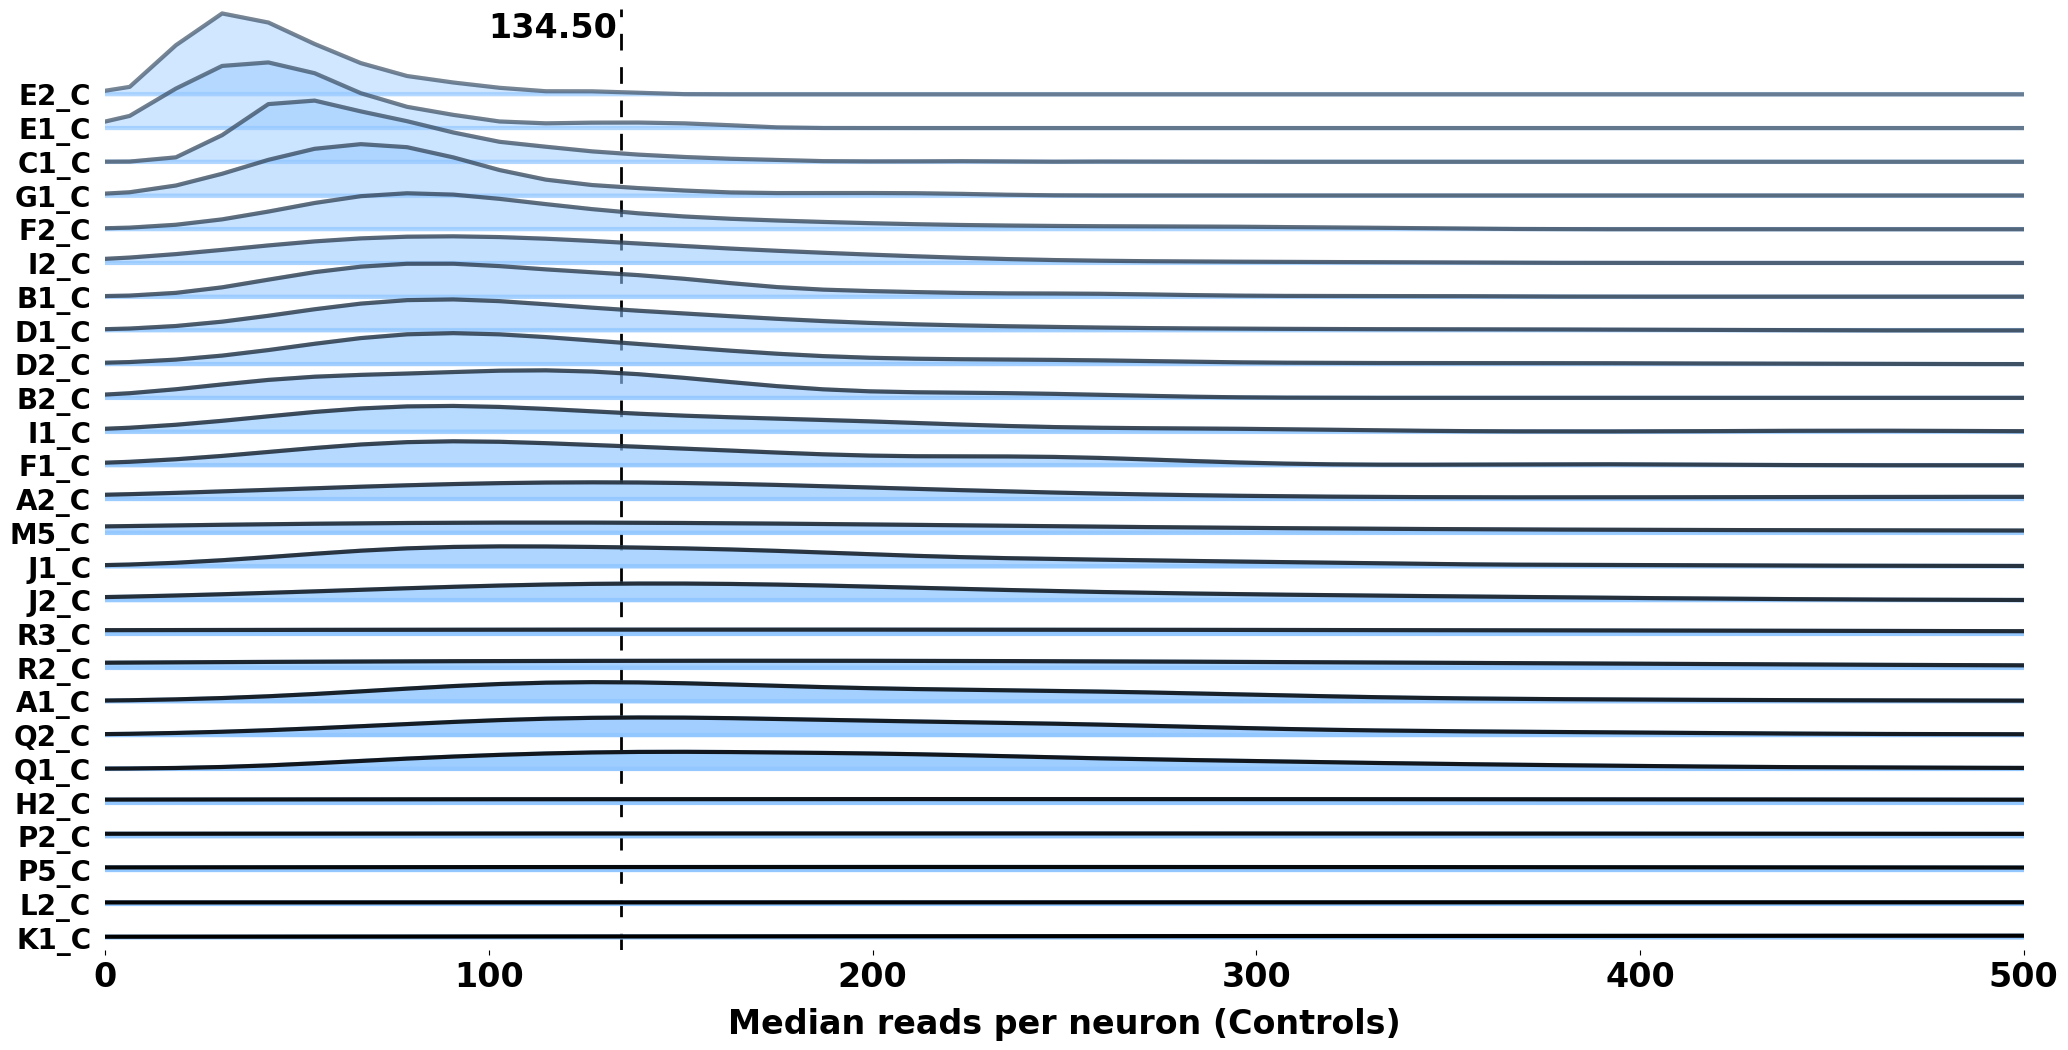

In [ ]:
median_median = np.median(np.array(medians_controls))

fig, axes = joyplot(
    control_df,
    by='ID',
    column='Value',
    kind="kde",
    color='#92C7FF',
    fade=True,
    linewidth=3,
    overlap=1,
    alpha=0.6,
   figsize=(20, 10)
)

axes[-1].axvline(
median_median,
color='k',
linestyle=(0, (6, 6)),  # 6 pt dash, 4 pt gap
linewidth=2,
zorder=100
)
    
plt.text(median_median - 1, 0.98, f"{median_median:.2f}", ha='right', va='center', color='k', fontsize = 24, fontweight='bold')
plt.xlabel('Median reads per neuron (Controls)', size=24, labelpad=10,  fontweight='bold')

for ax in axes:
    ax.tick_params(axis='y', labelsize=20)
    ax.tick_params(axis='x', labelsize=24)
    ax.set_axisbelow(False)
    ax.set_xlim(0,500)
    ax.set_xticks(np.arange(0, 501, 100))
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')

plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/supplementary/Coverage_plots/Coverage_Controls.svg", bbox_inches="tight", transparent=True)
plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/supplementary/Coverage_plots/Coverage_Controls.png", dpi=600, bbox_inches="tight", transparent=True)
plt.show()

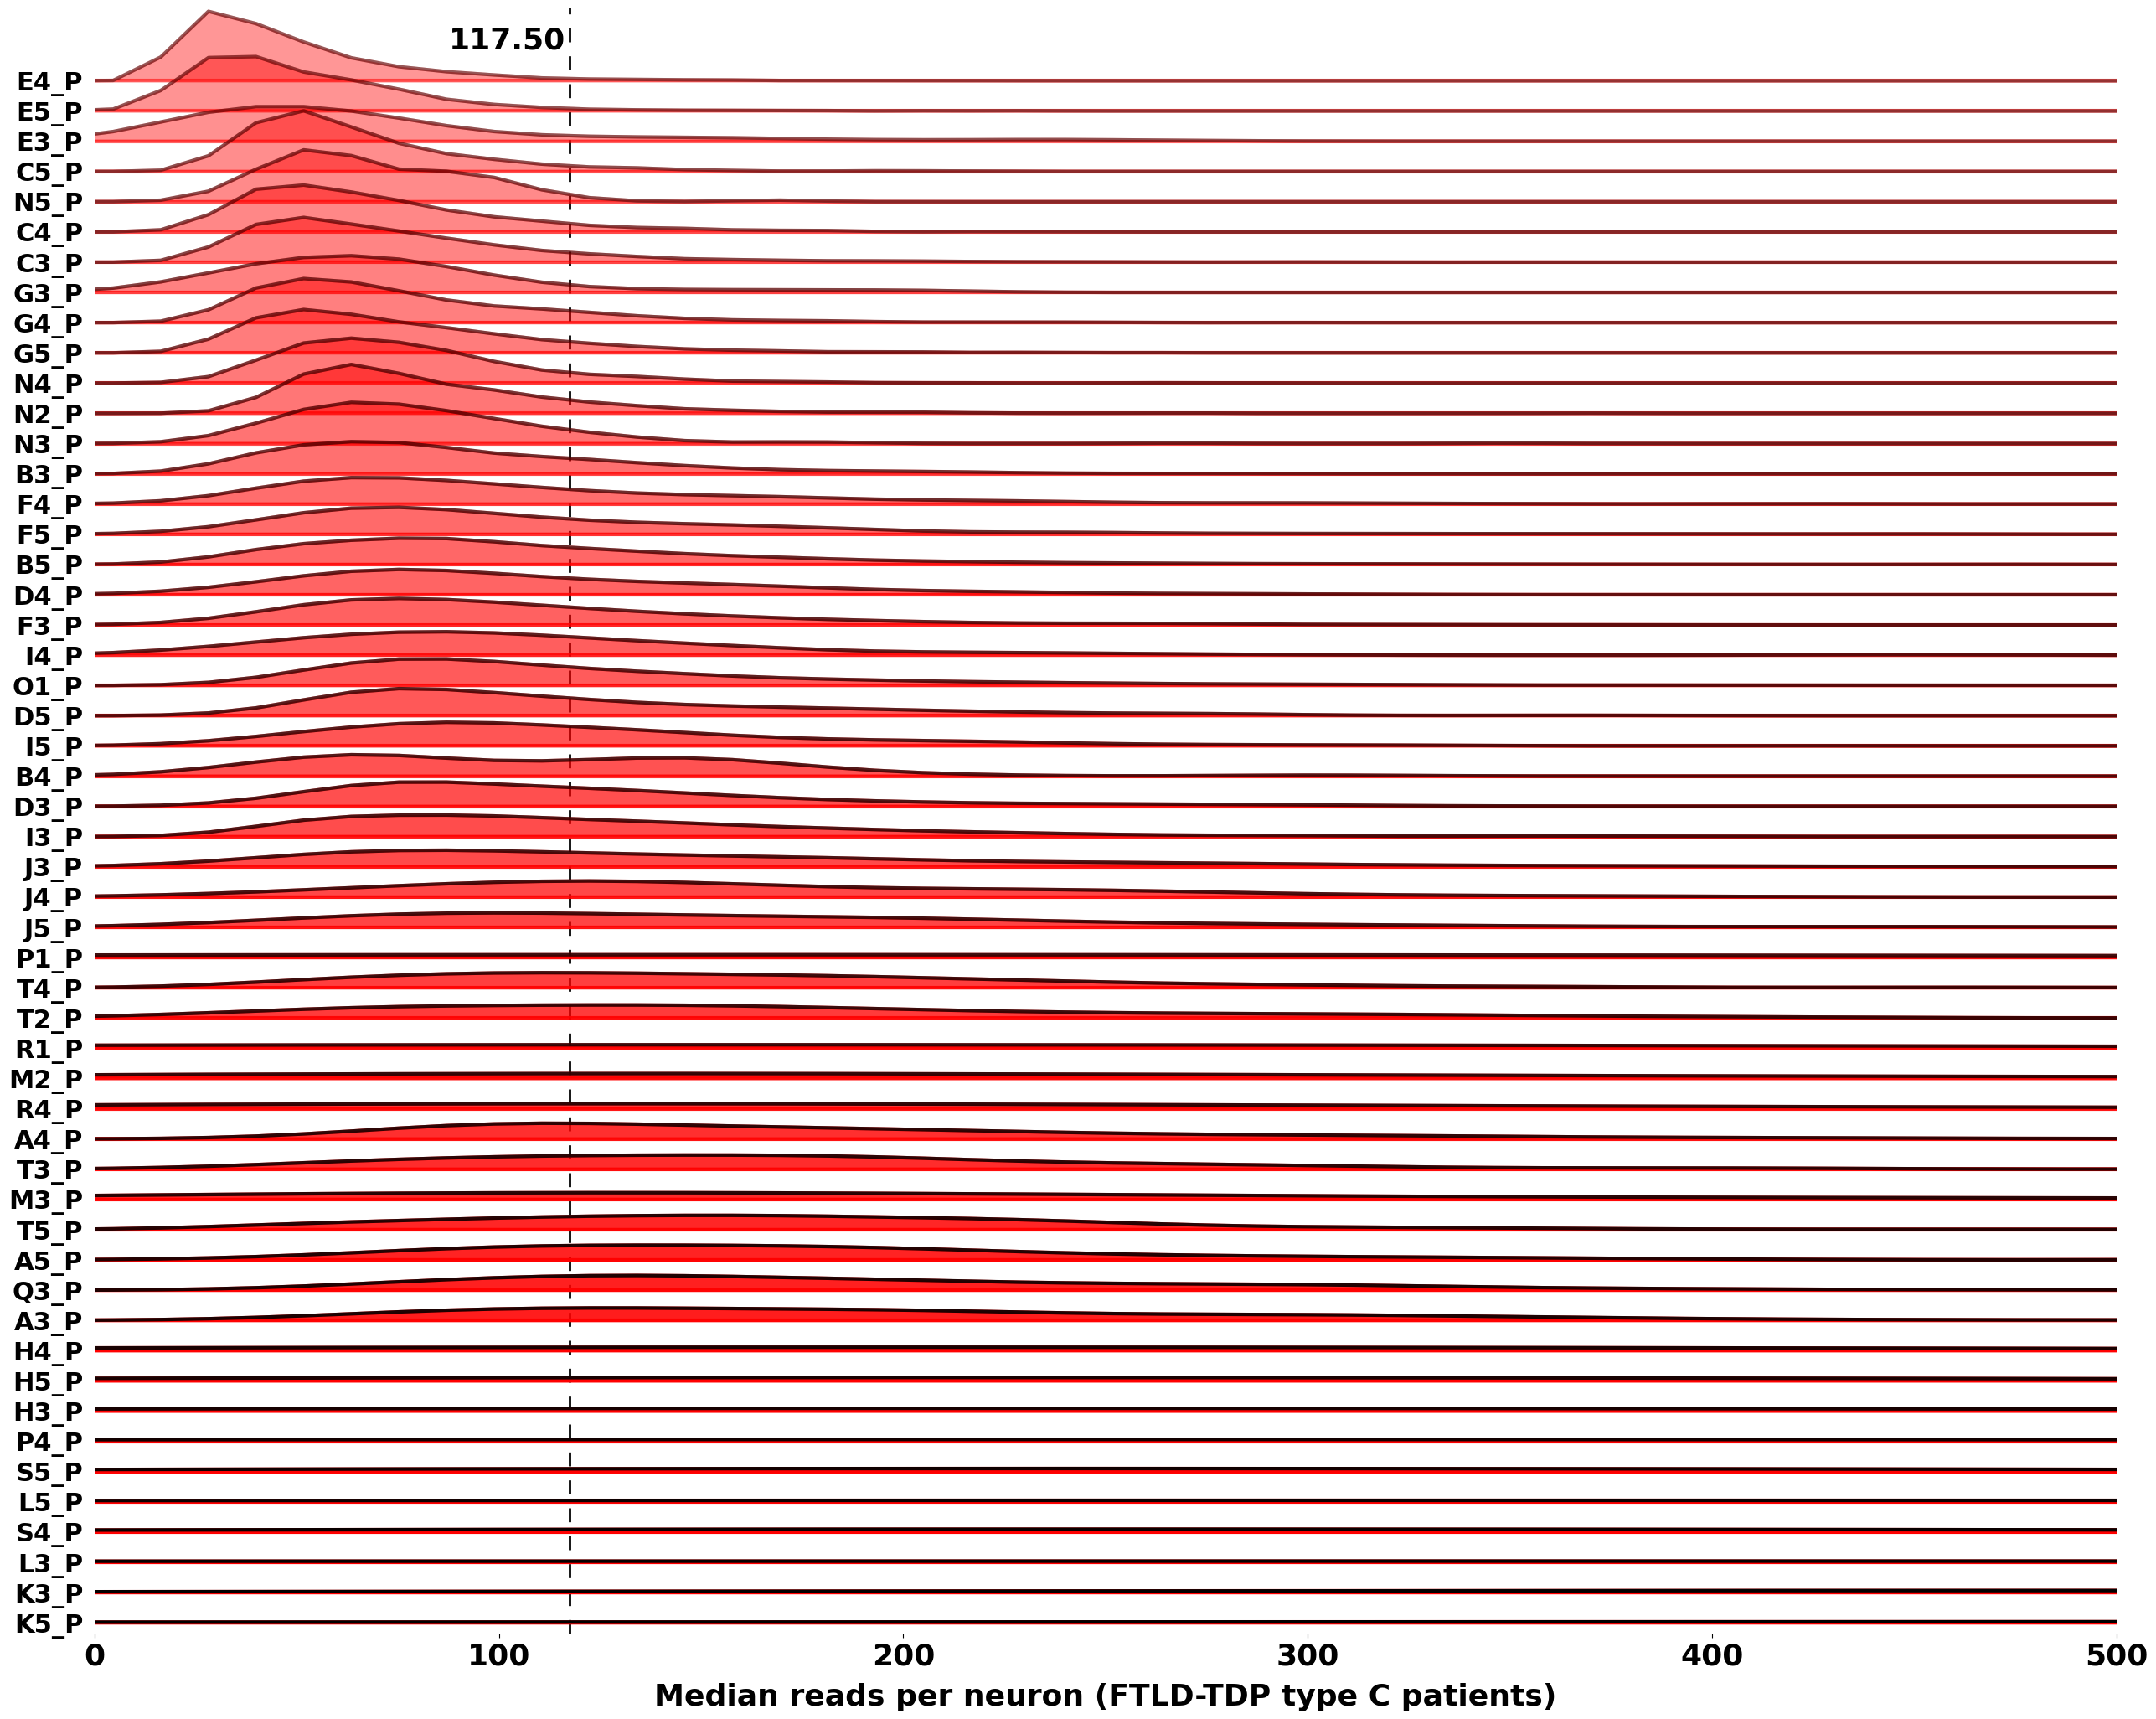

In [ ]:
median_median = np.median(np.array(medians_patients))

fig, axes = joyplot(
    condition_df,
    by='ID',
    column='Value',
    kind="kde",
    color='red',
    fade=True,
    linewidth=3,
    overlap=1,
    alpha=0.6,
   figsize=(25, 20)
)

axes[-1].axvline(
median_median,
color='k',
linestyle=(0, (6, 6)),  # 6 pt dash, 4 pt gap
linewidth=2,
zorder=100
)

plt.text(median_median - 1, 0.98, f"{median_median:.2f}", ha='right', va='center', color='k', fontsize = 26, fontweight='bold')

plt.xlabel('Median reads per neuron (FTLD-TDP type C patients)', size=26, labelpad = 10,  fontweight='bold')

for ax in axes:
    ax.tick_params(axis='y', labelsize=22)
    ax.tick_params(axis='x', labelsize=26)
    ax.set_axisbelow(False)
    ax.set_xlim(0,500)
    ax.set_xticks(np.arange(0, 501, 100))
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')


plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/supplementary/Coverage_plots/Coverage_Patients.svg", bbox_inches="tight", transparent=True)
plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/supplementary/Coverage_plots/Coverage_Patients.png", dpi=600, bbox_inches="tight", transparent=True)
plt.show()